In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
from xgboost import XGBRegressor
import joblib

In [26]:
df = pd.read_csv("Dataset.csv")
print(df.head())
print(df.shape)

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
(2000, 10)


In [27]:
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [28]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

X = df.drop(columns=['Price', 'Id'])
y = df['Price']

X_cat = pd.get_dummies(X[categorical_cols], drop_first=True)
X_num = X[[c for c in numeric_cols if c not in ['Price', 'Id']]].astype('float64')
X = pd.concat([X_num, X_cat], axis=1)

y = y.astype('float64')

valid_indices = ~(X.isnull().any(axis=1) | y.isnull())
X = X[valid_indices]
y = y[valid_indices]

X = X.replace([np.inf, -np.inf], np.nan).dropna(how='any', axis=0)
y = y[X.index]

X = X.fillna(X.mean())
y = y.fillna(y.mean())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2000, 12)
y shape: (2000,)


C:\Users\HP\AppData\Local\Temp\ipykernel_16528\3203038476.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

Training: 1600 | Testing: 400


In [30]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)

lr_train_mae = mean_absolute_error(y_train, y_pred_lr_train)
lr_test_mae = mean_absolute_error(y_test, y_pred_lr_test)
lr_train_r2 = r2_score(y_train, y_pred_lr_train)
lr_test_r2 = r2_score(y_test, y_pred_lr_test)

print(f"Linear Regression | Train MAE: {lr_train_mae:.2f} | Test MAE: {lr_test_mae:.2f}")
print(f"Linear Regression | Train R²: {lr_train_r2:.4f} | Test R²: {lr_test_r2:.4f}")

Linear Regression | Train MAE: 237121.93 | Test MAE: 243241.98
Linear Regression | Train R²: 0.0099 | Test R²: -0.0067


In [31]:
xgb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_test = xgb_model.predict(X_test)

xgb_train_mae = mean_absolute_error(y_train, y_pred_xgb_train)
xgb_test_mae = mean_absolute_error(y_test, y_pred_xgb_test)
xgb_train_r2 = r2_score(y_train, y_pred_xgb_train)
xgb_test_r2 = r2_score(y_test, y_pred_xgb_test)

print(f"XGBoost | Train MAE: {xgb_train_mae:.2f} | Test MAE: {xgb_test_mae:.2f}")
print(f"XGBoost | Train R²: {xgb_train_r2:.4f} | Test R²: {xgb_test_r2:.4f}")

XGBoost | Train MAE: 165674.74 | Test MAE: 252754.73
XGBoost | Train R²: 0.4769 | Test R²: -0.0987


In [32]:
results = {
    'Model': ['Linear Regression', 'XGBoost'],
    'Train MAE': [lr_train_mae, xgb_train_mae],
    'Test MAE': [lr_test_mae, xgb_test_mae],
    'Train R²': [lr_train_r2, xgb_train_r2],
    'Test R²': [lr_test_r2, xgb_test_r2]
}

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))


Model Comparison:
            Model     Train MAE      Test MAE  Train R²   Test R²
Linear Regression 237121.929734 243241.977588  0.009856 -0.006718
          XGBoost 165674.743887 252754.730508  0.476869 -0.098730


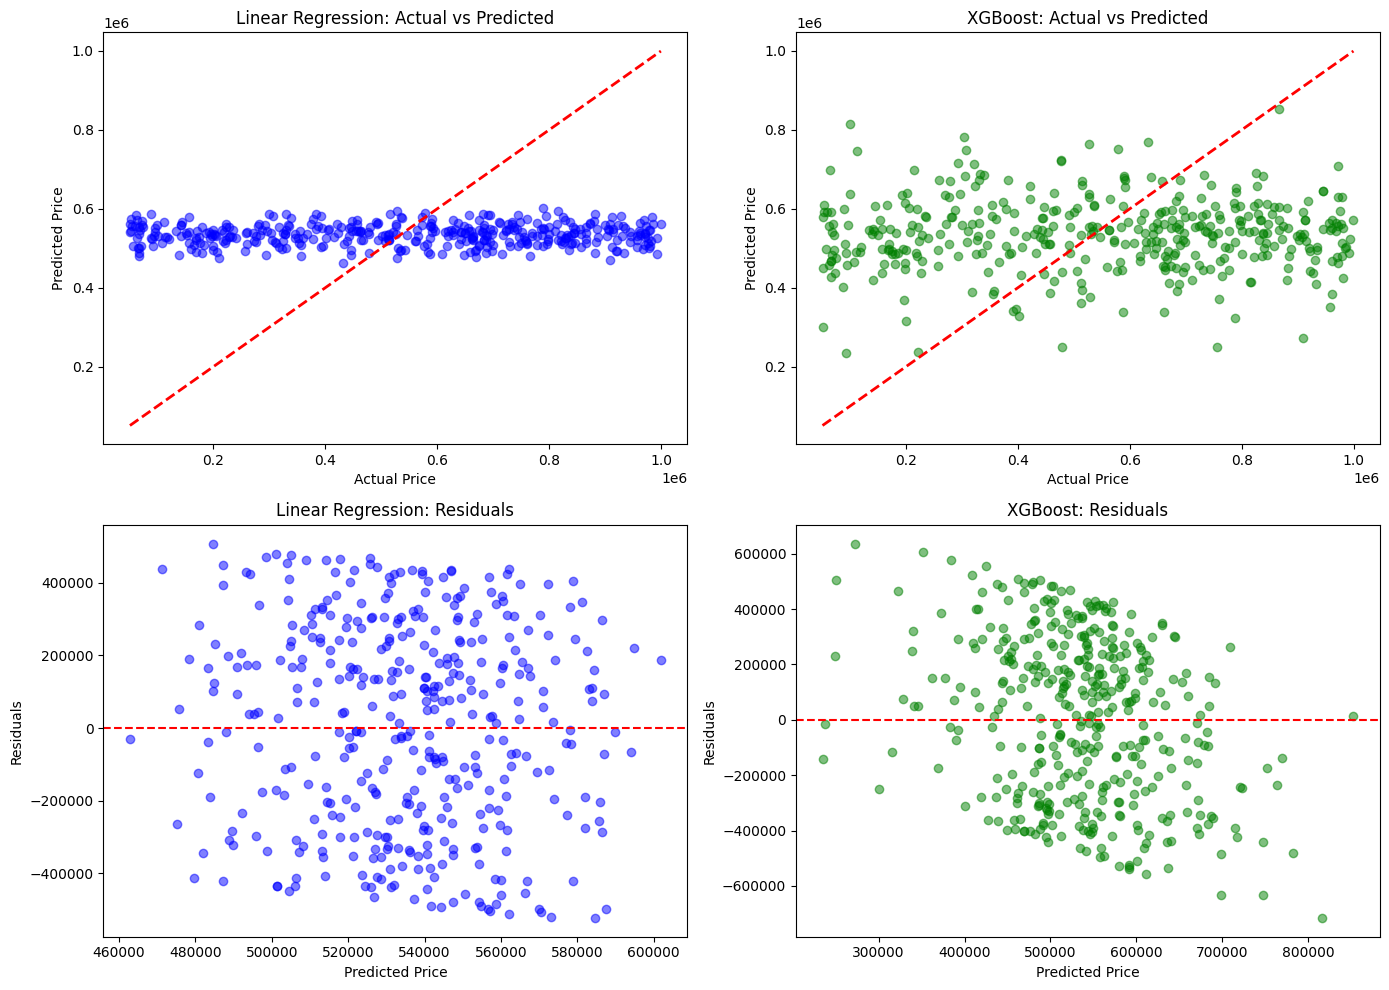

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_test, y_pred_lr_test, alpha=0.5, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price')
axes[0, 0].set_ylabel('Predicted Price')
axes[0, 0].set_title('Linear Regression: Actual vs Predicted')

axes[0, 1].scatter(y_test, y_pred_xgb_test, alpha=0.5, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Price')
axes[0, 1].set_ylabel('Predicted Price')
axes[0, 1].set_title('XGBoost: Actual vs Predicted')

residuals_lr = y_test - y_pred_lr_test
axes[1, 0].scatter(y_pred_lr_test, residuals_lr, alpha=0.5, color='blue')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Price')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Linear Regression: Residuals')

residuals_xgb = y_test - y_pred_xgb_test
axes[1, 1].scatter(y_pred_xgb_test, residuals_xgb, alpha=0.5, color='green')
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted Price')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('XGBoost: Residuals')

plt.tight_layout()
plt.show()

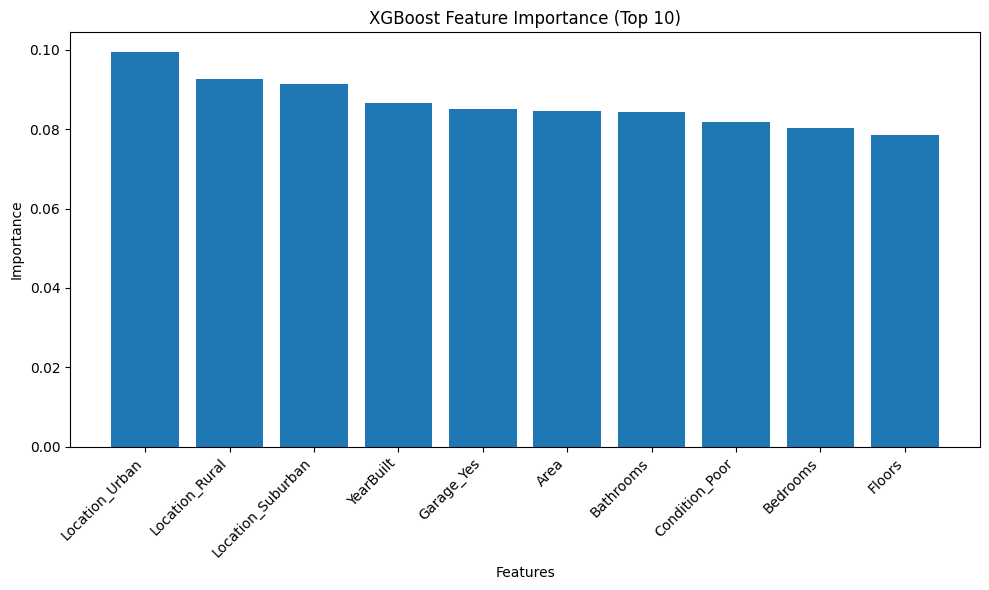


Top 10 Features:
1. Location_Urban: 0.0994
2. Location_Rural: 0.0926
3. Location_Suburban: 0.0914
4. YearBuilt: 0.0866
5. Garage_Yes: 0.0850
6. Area: 0.0845
7. Bathrooms: 0.0842
8. Condition_Poor: 0.0819
9. Bedrooms: 0.0802
10. Floors: 0.0785


In [34]:
importances = xgb_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.bar(range(10), importances[indices])
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('XGBoost Feature Importance (Top 10)')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

In [35]:
joblib.dump(lr_model, 'linear_regression_model.pkl')
joblib.dump(xgb_model, 'xgboost_model.pkl')

print("Models saved successfully!")
print("- linear_regression_model.pkl")
print("- xgboost_model.pkl")

Models saved successfully!
- linear_regression_model.pkl
- xgboost_model.pkl


In [36]:
print("="*60)
print("HOUSE PRICE PREDICTION PROJECT SUMMARY")
print("="*60)
print(f"\nDataset Shape: {df.shape}")
print(f"Training Samples: {X_train.shape[0]} | Test Samples: {X_test.shape[0]}")
print(f"\nLinear Regression Test MAE: ${lr_test_mae:,.2f}")
print(f"XGBoost Test MAE: ${xgb_test_mae:,.2f}")
print(f"\nBest Model: {'XGBoost' if xgb_test_mae < lr_test_mae else 'Linear Regression'}")
print(f"R² Score (XGBoost): {xgb_test_r2:.4f}")
print("="*60)

HOUSE PRICE PREDICTION PROJECT SUMMARY

Dataset Shape: (2000, 10)
Training Samples: 1600 | Test Samples: 400

Linear Regression Test MAE: $243,241.98
XGBoost Test MAE: $252,754.73

Best Model: Linear Regression
R² Score (XGBoost): -0.0987
